In [1]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display as dp
import os

In [7]:


# 종목명과 파일 경로 정의
tickers = ['엔비디아', '알파벳', '애플']
paths = [
    '/home/nshawny/AI project 2/personal_data/stock/overseas/엔비디아.csv',
    '/home/nshawny/AI project 2/personal_data/stock/overseas/알파벳.csv',
    '/home/nshawny/AI project 2/personal_data/stock/overseas/애플.csv'
]

# zip으로 묶어서 dict로 만들기
stock_dict = {name: pd.read_csv(path) for name, path in zip(tickers, paths)}

# 확인
for name, df in stock_dict.items():
    print(f'{name}: {df.shape}')


엔비디아: (1255, 8)
알파벳: (1255, 8)
애플: (1255, 8)


In [5]:


for name, df in stock_dict.items():
    df['High_Low_Range'] = (df['High'] - df['Low']) / df['Close']
    df['Volatility_20'] = df['Close'].rolling(20).std()
    df['PriceChange_1d'] = df['Close'].pct_change()
    df['PriceChange_3d'] = df['Close'].pct_change(3)
    df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

    # 기술 지표 (예: RSI, MACD, OBV)
    df['RSI'] = ta.rsi(df['Close'], length=14)
    macd = ta.macd(df['Close'])
    df['MACD'] = macd['MACD_12_26_9']
    df['MACD_signal'] = macd['MACDs_12_26_9']
    df['OBV'] = ta.obv(df['Close'], df['Volume'])

    # 다시 저장
    stock_dict[name] = df


In [8]:
# ====================
# ✅ 1. 단일 종목 피처 생성 함수
# ====================

def generate_features(df):
    """
    [피처 생성 파이프라인]
    - 기술적 지표
    - 수익률 라벨
    - 조건 기반 flag
    - 파생 비율형 변수
    """

    # 1️⃣ 이동평균
    df['SMA_20'] = ta.sma(df['Close'], length=20)
    df['EMA_20'] = ta.ema(df['Close'], length=20)

    # 2️⃣ RSI
    df['RSI_14'] = ta.rsi(df['Close'], length=14)

    # 3️⃣ MACD
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df['MACD'] = macd['MACD_12_26_9']
    df['MACD_signal'] = macd['MACDs_12_26_9']
    df['MACD_diff'] = df['MACD'] - df['MACD_signal']

    # 4️⃣ OBV
    df['OBV'] = ta.obv(df['Close'], df['Volume'])

    # 5️⃣ Bollinger Bands
    bb = ta.bbands(df['Close'], length=20, std=2)
    df['BBU'] = bb['BBU_20_2.0']
    df['BBM'] = bb['BBM_20_2.0']
    df['BBL'] = bb['BBL_20_2.0']

    # 6️⃣ Stochastic Oscillator
    stoch = ta.stoch(df['High'], df['Low'], df['Close'], k=14, d=3)
    df['STOCHk'] = stoch['STOCHk_14_3_3']
    df['STOCHd'] = stoch['STOCHd_14_3_3']

    # 7️⃣ 수익률 라벨
    df['PriceChange_1d'] = df['Close'].pct_change().shift(-1)
    df['PriceChange_3d'] = (df['Close'].shift(-3) - df['Close']) / df['Close']
    df['PriceChange_5d'] = (df['Close'].shift(-5) - df['Close']) / df['Close']
    df['MaxGain_5d'] = (df['High'].rolling(5).max().shift(-5) - df['Close']) / df['Close']
    df['IsJump_5d'] = (df['MaxGain_5d'] > 0.03).astype(int)

    # 8️⃣ 조건 기반 flag
    df['MACD_cross'] = (df['MACD'] > df['MACD_signal']).astype(int)
    df['RSI_oversold_flag'] = (df['RSI_14'] < 30).astype(int)
    df['OBV_rising'] = (df['OBV'].diff() > 0).astype(int)
    df['BB_touch_lower'] = (df['Close'] < df['BBL']).astype(int)
    df['STOCH_cross'] = (df['STOCHk'] > df['STOCHd']).astype(int)

    # 9️⃣ 파생 비율형 변수
    df['BB_ratio'] = (df['Close'] - df['BBM']) / (df['BBU'] - df['BBL'])
    df['RSI_gap'] = df['RSI_14'] - 50

    return df

In [10]:
features_dict = {}

for name, df in stock_dict.items():
    print(f'Processing {name} ...')
    df_features = generate_features(df.copy())
    features_dict[name] = df_features
    # CSV 저장 (옵션)
    # df_features.to_csv(f'./output/{name}_features.csv', index=False)

print('✅ All features generated and saved.')

Processing 엔비디아 ...
Processing 알파벳 ...
Processing 애플 ...
✅ All features generated and saved.


In [40]:
# ================
# ✅ 단일 종목 EDA 플롯 함수
# ================
def plot_full_eda(df, name, save_path=None):
    plt.rcParams['font.family'] = 'NanumGothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False
    """
    📌 1개의 종목 DataFrame에서 주요 EDA 플롯을 생성
    - 종가 추이
    - 로그수익률 히스토그램
    - RSI, MACD, OBV, BB_ratio 분포
    - 조건 flag 빈도
    """
    plt.figure(figsize=(16, 12))
    
    # 1️⃣ 종가 시계열
    plt.subplot(3, 2, 1)
    plt.plot(df['Date'], df['Close'], color='blue')
    plt.title(f'{name} - Close Price')
    plt.xlabel('Date')
    plt.ylabel('Price')
    # ✅ X축 간격 줄이기
    plt.xticks(df['Date'][::90], rotation=45)  # 90일 간격으로 라벨 찍기

    # 2️⃣ 로그수익률 히스토그램
    logret = np.log(df['Close']).diff()
    plt.subplot(3, 2, 2)
    plt.hist(logret.dropna(), bins=50, color='gray')
    plt.title(f'{name} - Log Return Distribution')
    plt.xlabel('Log Return')
    plt.ylabel('Frequency')

    # 3️⃣ RSI 분포
    plt.subplot(3, 2, 3)
    df['RSI_14'].hist(bins=30, color='purple')
    plt.title(f'{name} - RSI(14) Distribution')
    plt.xlabel('RSI')
    plt.ylabel('Frequency')

    # 4️⃣ MACD_diff 분포
    plt.subplot(3, 2, 4)
    df['MACD_diff'].hist(bins=30, color='green')
    plt.title(f'{name} - MACD_diff Distribution')
    plt.xlabel('MACD_diff')
    plt.ylabel('Frequency')

    # 5️⃣ OBV 분포
    plt.subplot(3, 2, 5)
    df['OBV'].hist(bins=30, color='orange')
    plt.title(f'{name} - OBV Distribution')
    plt.xlabel('OBV')
    plt.ylabel('Frequency')

    # 6️⃣ BB_ratio 분포
    plt.subplot(3, 2, 6)
    df['BB_ratio'].hist(bins=30, color='red')
    plt.title(f'{name} - Bollinger Band Ratio')
    plt.xlabel('BB_ratio')
    plt.ylabel('Frequency')

    plt.tight_layout()
    if save_path:
        plt.savefig(f'{save_path}/{name}_EDA.png')
    plt.show()

In [41]:
# =======================
# ✅ 조건 flag 시각화 함수
# =======================
def plot_condition_flags(df, name, save_path=None):
    """
    조건 flag 변수들의 발생 빈도 barplot
    """
    plt.rcParams['font.family'] = 'NanumGothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False
    flags = [
        'MACD_cross', 'RSI_oversold_flag',
        'OBV_rising', 'BB_touch_lower', 'STOCH_cross'
    ]

    values = [df[col].sum() for col in flags]

    plt.figure(figsize=(8, 6))
    plt.bar(flags, values, color='teal')
    plt.title(f'{name} - Condition Flags Occurrences')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    if save_path:
        plt.savefig(f'{save_path}/{name}_Flags.png')
    plt.show()

🖼️ Plotting EDA for 엔비디아 ...


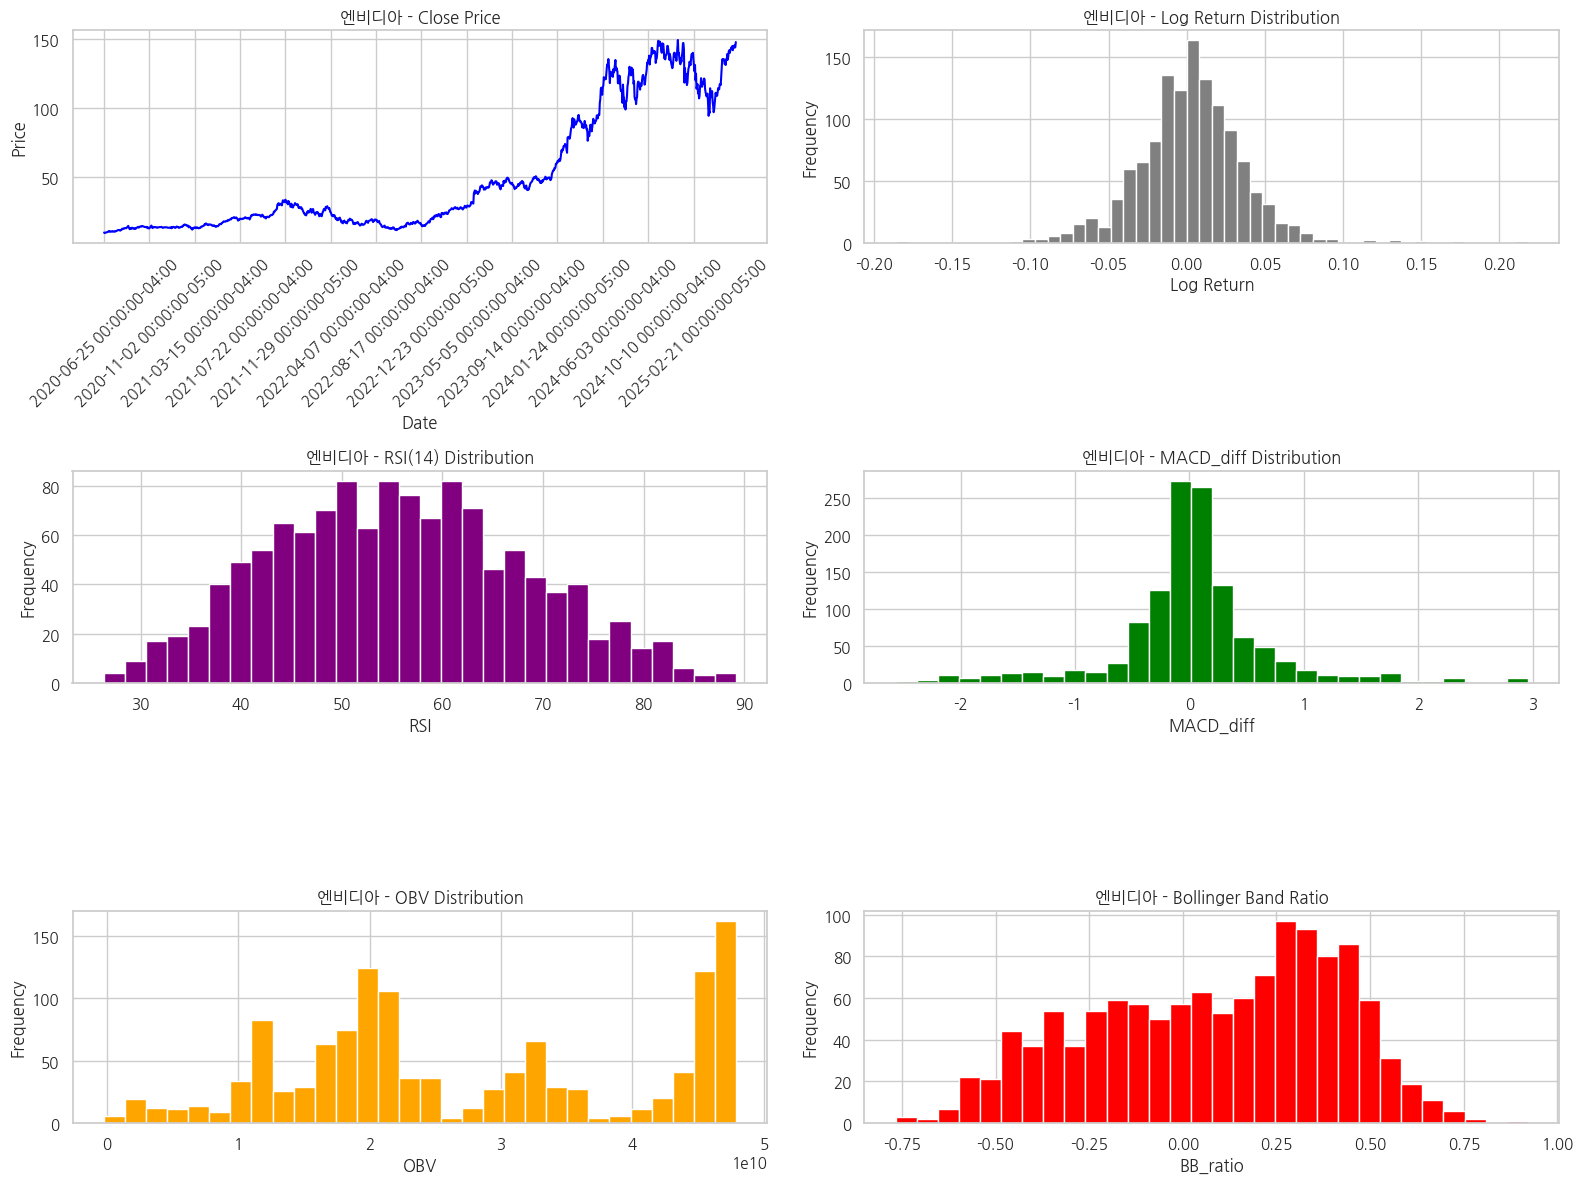

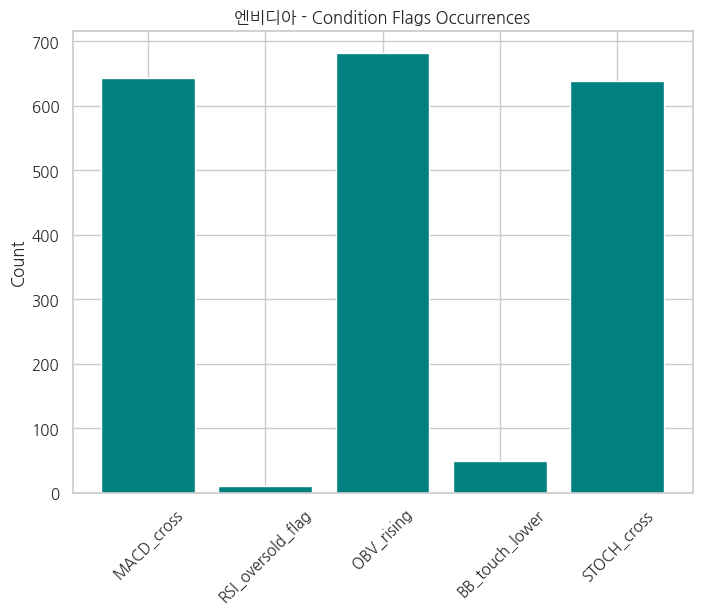

🖼️ Plotting EDA for 알파벳 ...


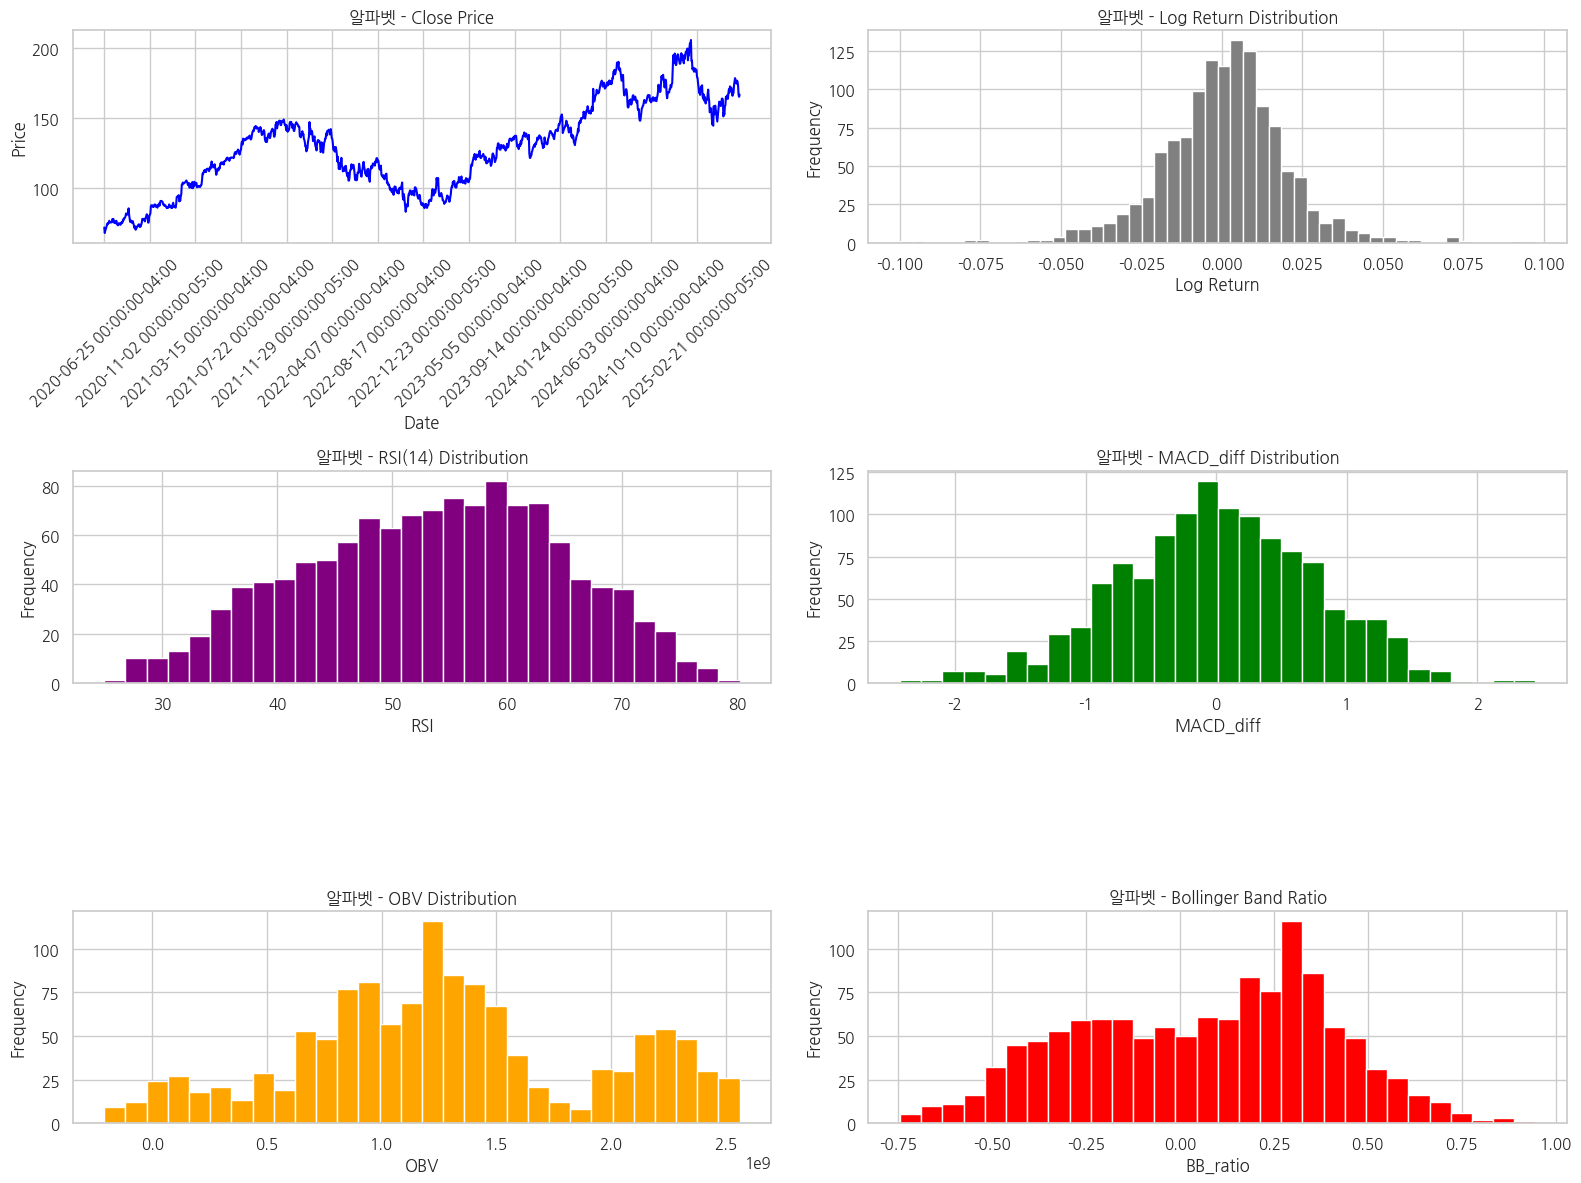

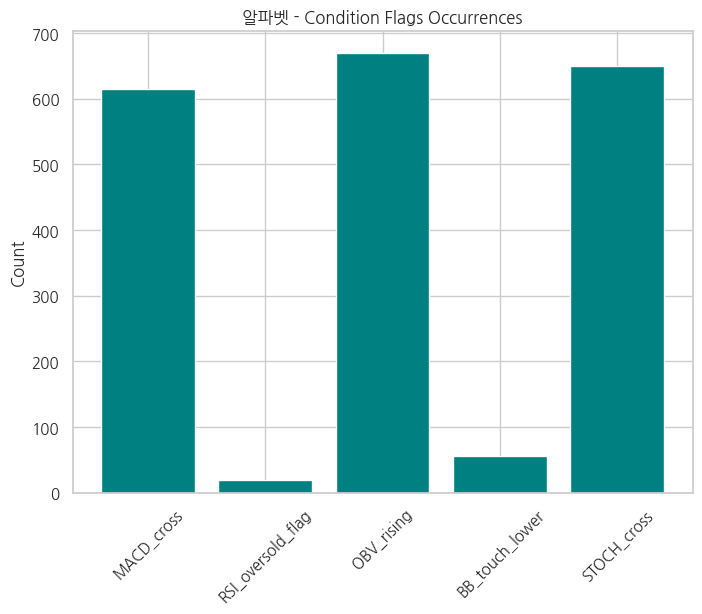

🖼️ Plotting EDA for 애플 ...


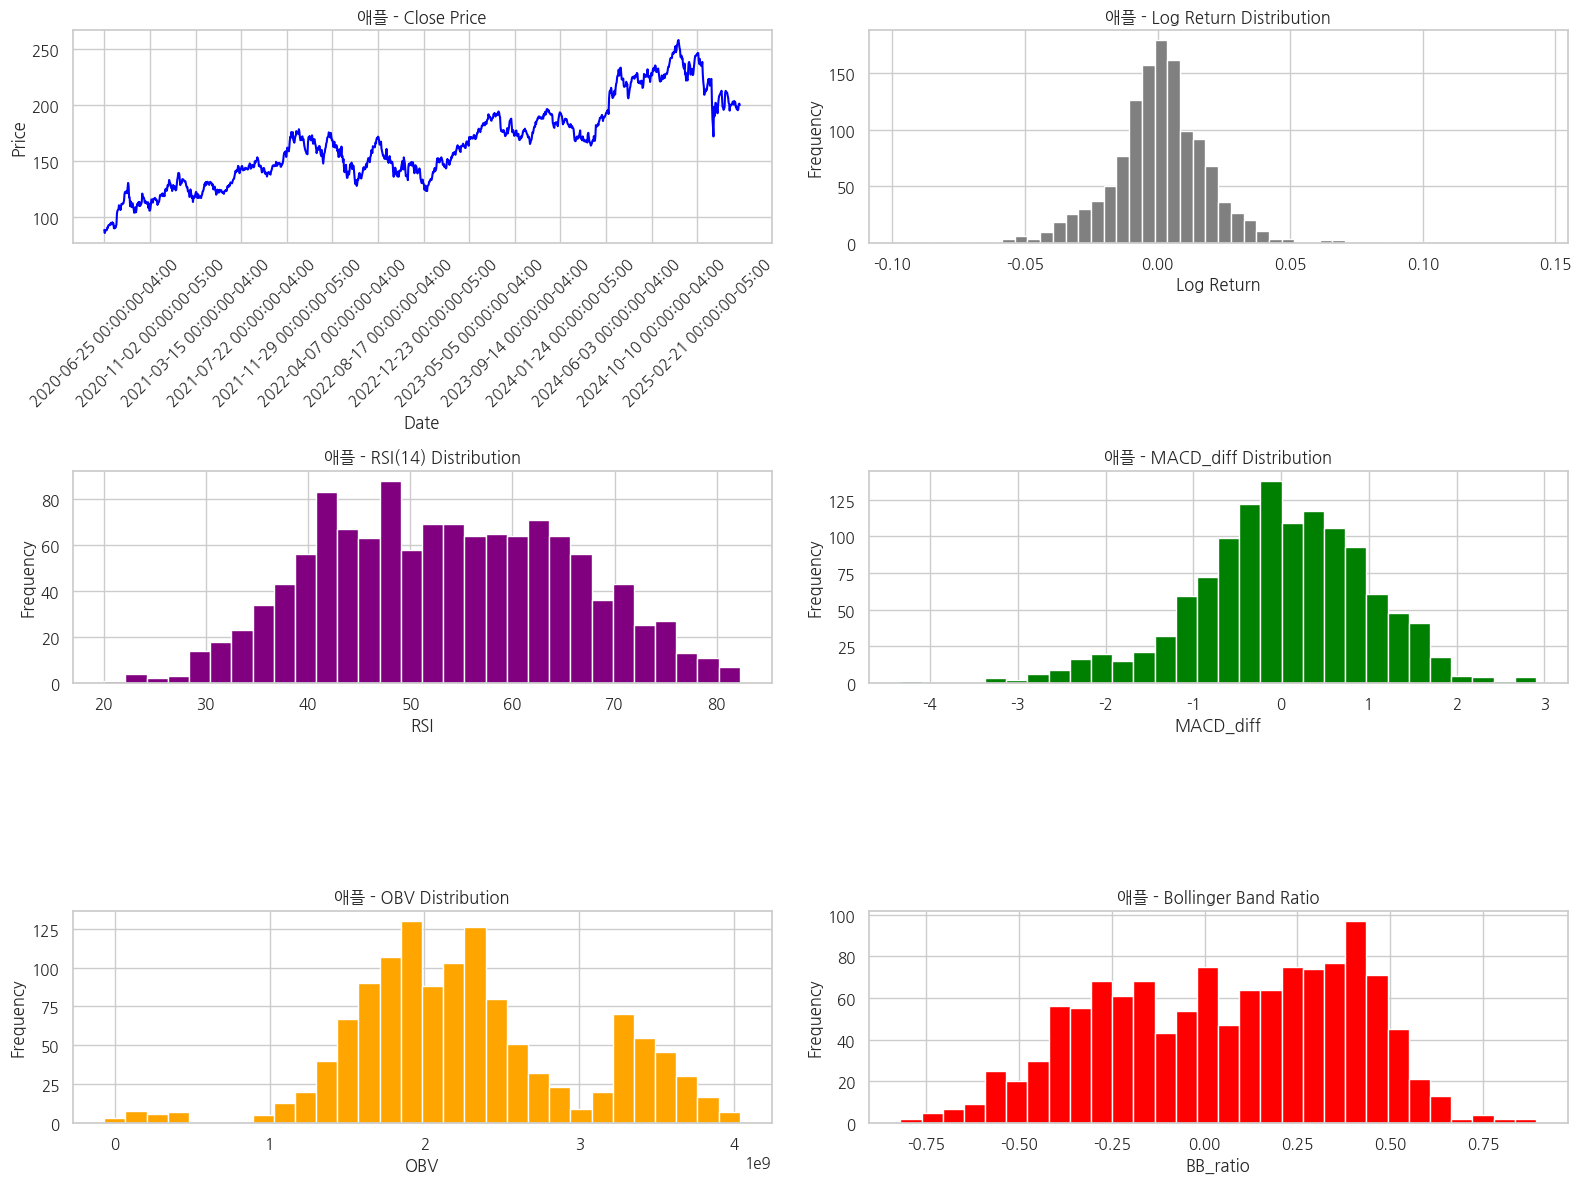

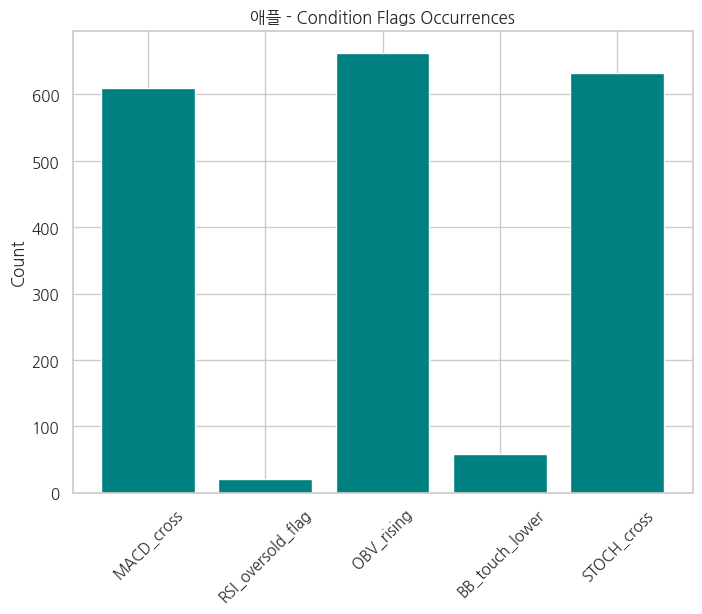

In [42]:
# 예시 저장 경로
save_dir = '/home/nshawny/AI project 2/personal_data/eda_plots'

for name, df in features_dict.items():
    print(f'🖼️ Plotting EDA for {name} ...')
    plot_full_eda(df, name, save_path=save_dir)
    plot_condition_flags(df, name, save_path=save_dir)

In [43]:
# seaborn 스타일 세팅
sns.set_theme(style="whitegrid")

In [44]:
def plot_full_eda_seaborn(df, name, save_path=None):
    plt.rcParams['font.family'] = 'NanumGothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False
    """
    ✅ 주요 지표 분포를 seaborn 스타일로 플로팅 + 저장 + 화면 출력
    - 종가 시계열
    - 로그수익률 히스토그램 (kde 포함)
    - RSI, MACD_diff, OBV, BB_ratio → boxplot
    """
    plt.figure(figsize=(16, 12))

    # 1️⃣ 종가 시계열
    plt.subplot(3, 2, 1)
    sns.lineplot(x=df['Date'], y=df['Close'], color='blue')
    plt.title(f'{name} - Close Price')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.xticks(rotation=45)
    # ✅ X축 간격 줄이기
    plt.xticks(df['Date'][::90], rotation=45)  # 90일 간격으로 라벨 찍기

    # 2️⃣ 로그수익률 히스토그램
    logret = np.log(df['Close']).diff()
    plt.subplot(3, 2, 2)
    sns.histplot(logret.dropna(), bins=50, kde=True, color='gray')
    plt.title(f'{name} - Log Return Distribution')
    plt.xlabel('Log Return')
    plt.ylabel('Frequency')

    # 3️⃣ RSI Boxplot
    plt.subplot(3, 2, 3)
    sns.boxplot(x=df['RSI_14'], color='purple')
    plt.title(f'{name} - RSI(14) Boxplot')
    plt.xlabel('RSI')

    # 4️⃣ MACD_diff Boxplot
    plt.subplot(3, 2, 4)
    sns.boxplot(x=df['MACD_diff'], color='green')
    plt.title(f'{name} - MACD_diff Boxplot')
    plt.xlabel('MACD_diff')

    # 5️⃣ OBV Boxplot
    plt.subplot(3, 2, 5)
    sns.boxplot(x=df['OBV'], color='orange')
    plt.title(f'{name} - OBV Boxplot')
    plt.xlabel('OBV')

    # 6️⃣ BB_ratio Boxplot
    plt.subplot(3, 2, 6)
    sns.boxplot(x=df['BB_ratio'], color='red')
    plt.title(f'{name} - Bollinger Band Ratio Boxplot')
    plt.xlabel('BB_ratio')

    plt.tight_layout()

    # ✅ 저장
    if save_path:
        plt.savefig(f'{save_path}/{name}_EDA_sns.png')
        print(f'✅ Saved: {save_path}/{name}_EDA_sns.png')

    # ✅ 즉시 화면 출력
    plt.show()


In [45]:
def plot_condition_flags_seaborn(df, name, save_path=None):
    plt.rcParams['font.family'] = 'NanumGothic'
    # 마이너스 기호 깨짐 방지
    plt.rcParams['axes.unicode_minus'] = False
    """
    ✅ 조건 flag 변수들의 발생 카운트 seaborn barplot
    """
    flags = [
        'MACD_cross', 'RSI_oversold_flag',
        'OBV_rising', 'BB_touch_lower', 'STOCH_cross'
    ]

    counts = [df[col].sum() for col in flags]
    flag_df = pd.DataFrame({'Flag': flags, 'Count': counts})

    plt.figure(figsize=(8, 6))
    sns.barplot(data=flag_df, x='Flag', y='Count', palette='viridis')
    plt.title(f'{name} - Condition Flags Occurrences')
    plt.ylabel('Count')
    plt.xticks(rotation=45)

    # ✅ 저장
    if save_path:
        plt.savefig(f'{save_path}/{name}_Flags_sns.png')
        print(f'✅ Saved: {save_path}/{name}_Flags_sns.png')

    # ✅ 즉시 출력
    plt.show()


🖼️ Seaborn EDA Plotting for 엔비디아 ...
✅ Saved: /home/nshawny/AI project 2/personal_data/eda_plots/엔비디아_EDA_sns.png


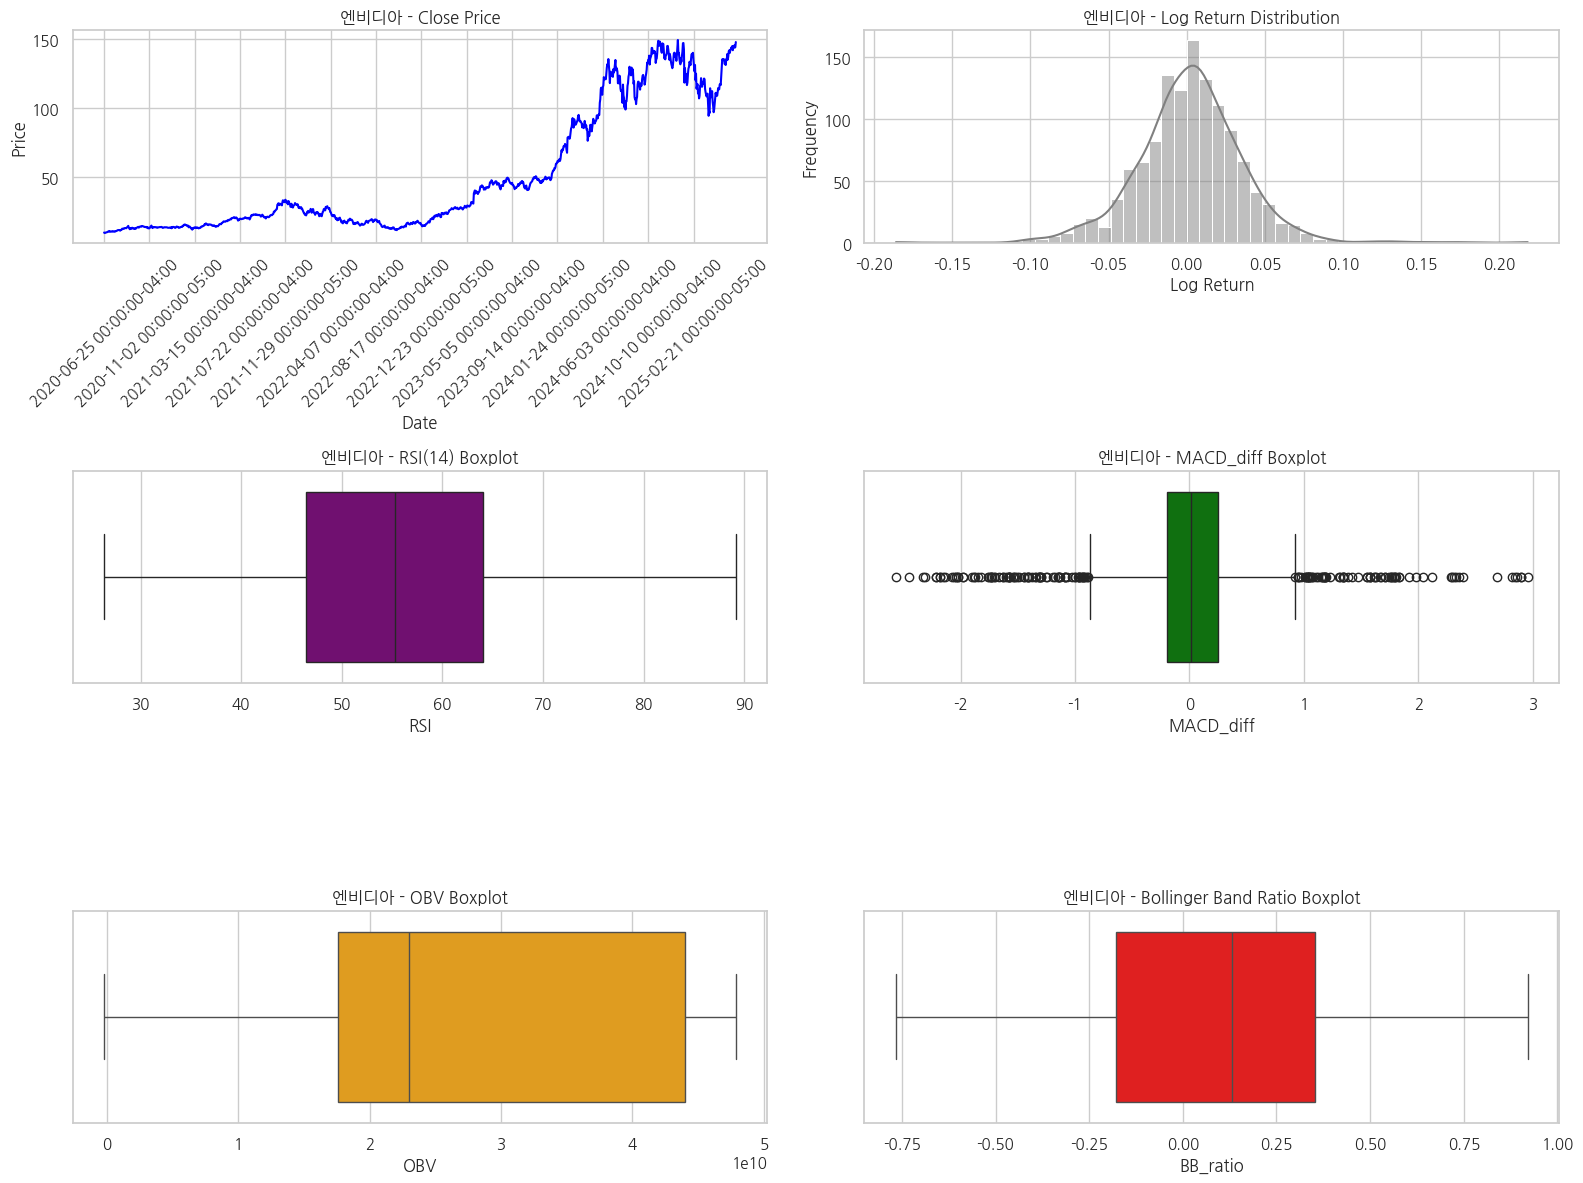

✅ Saved: /home/nshawny/AI project 2/personal_data/eda_plots/엔비디아_Flags_sns.png


/tmp/ipykernel_1037/2854274865.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=flag_df, x='Flag', y='Count', palette='viridis')


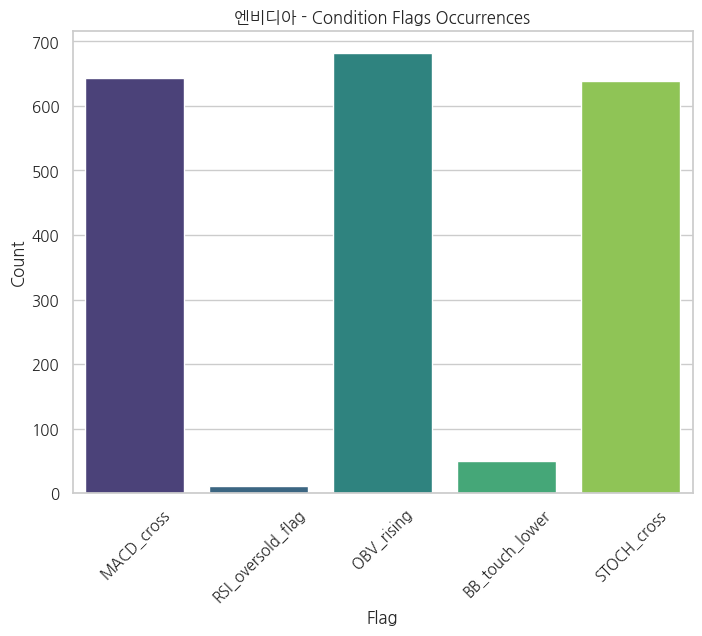

🖼️ Seaborn EDA Plotting for 알파벳 ...
✅ Saved: /home/nshawny/AI project 2/personal_data/eda_plots/알파벳_EDA_sns.png


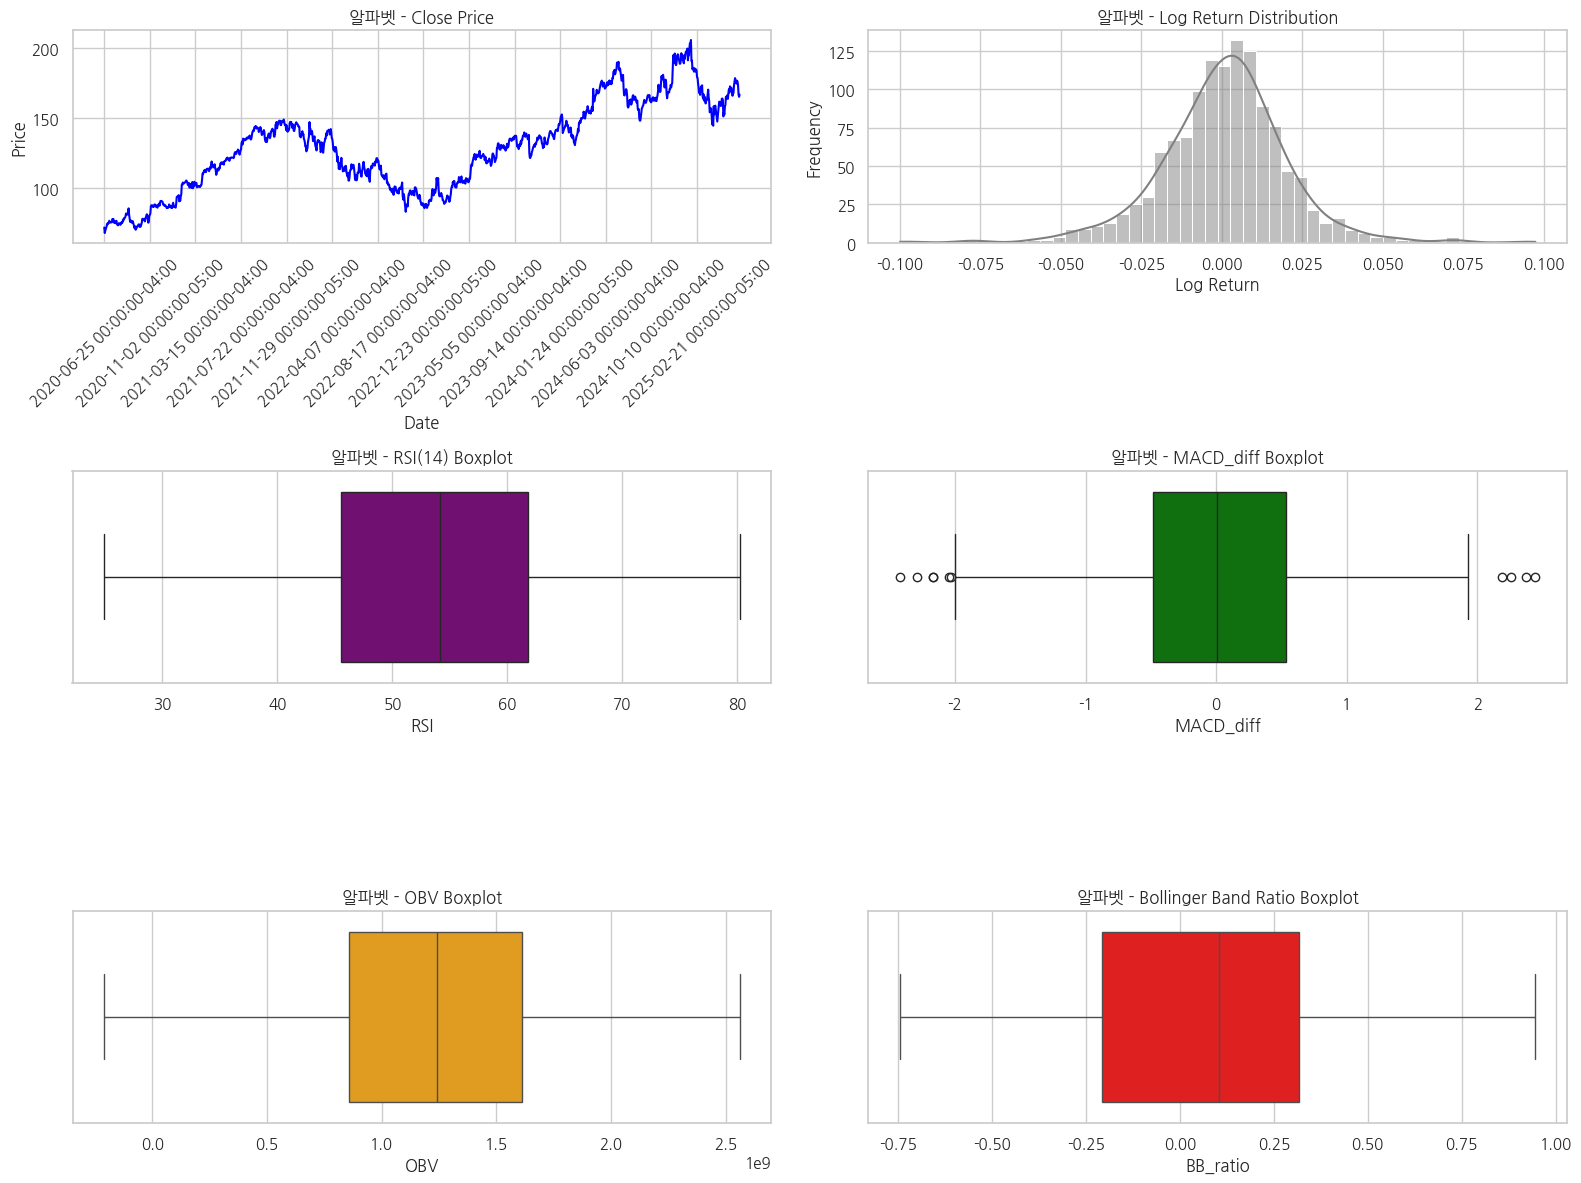

✅ Saved: /home/nshawny/AI project 2/personal_data/eda_plots/알파벳_Flags_sns.png


/tmp/ipykernel_1037/2854274865.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=flag_df, x='Flag', y='Count', palette='viridis')


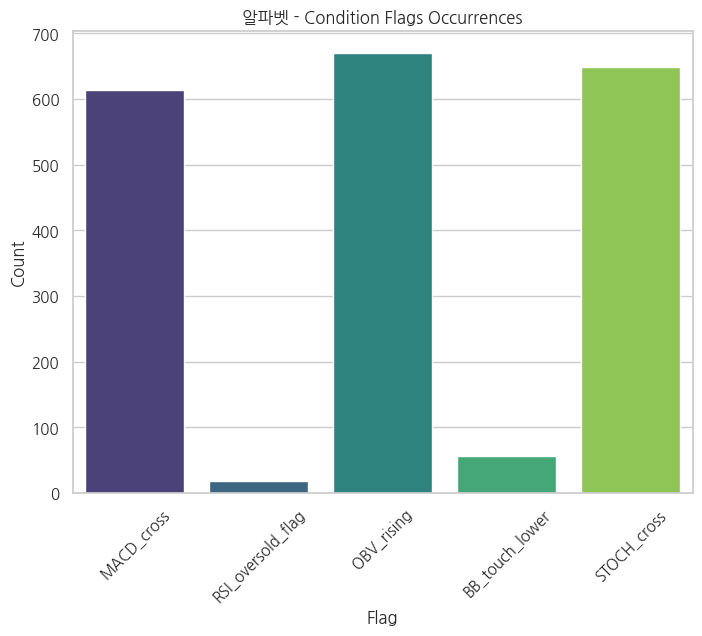

🖼️ Seaborn EDA Plotting for 애플 ...
✅ Saved: /home/nshawny/AI project 2/personal_data/eda_plots/애플_EDA_sns.png


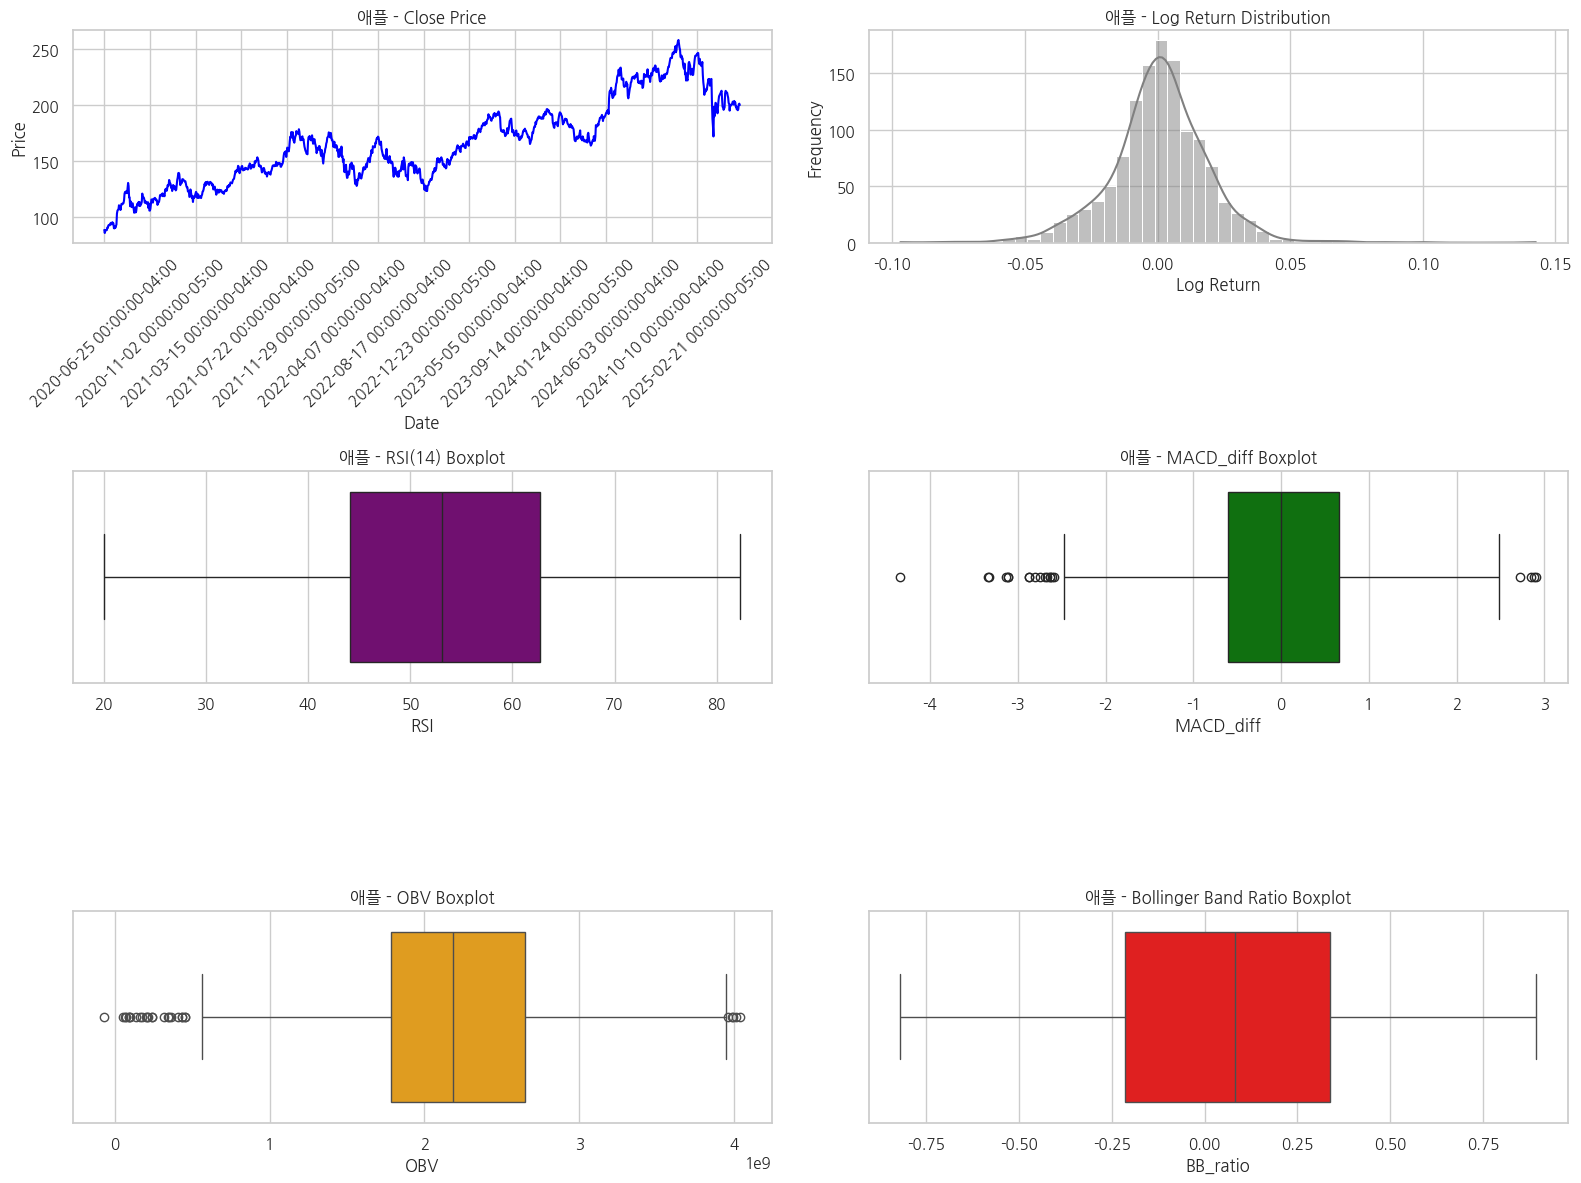

✅ Saved: /home/nshawny/AI project 2/personal_data/eda_plots/애플_Flags_sns.png


/tmp/ipykernel_1037/2854274865.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=flag_df, x='Flag', y='Count', palette='viridis')


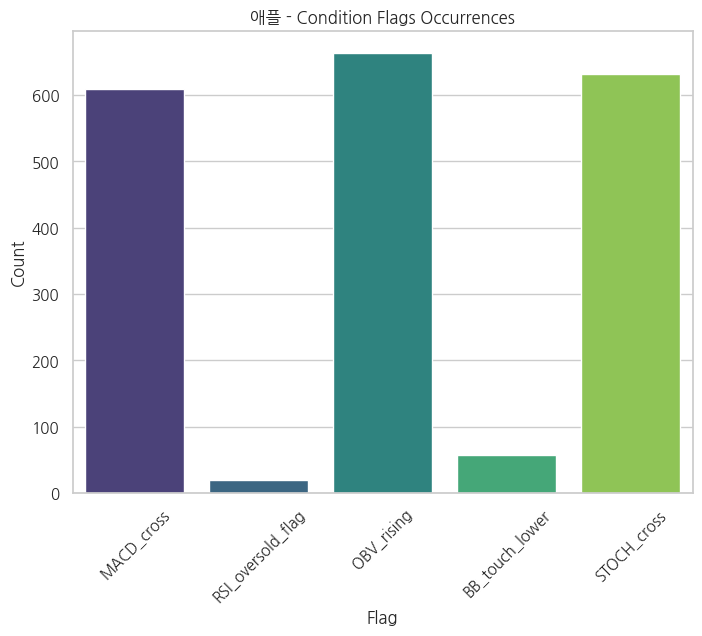

In [46]:
save_dir = '/home/nshawny/AI project 2/personal_data/eda_plots'

for name, df in features_dict.items():
    print(f'🖼️ Seaborn EDA Plotting for {name} ...')
    plot_full_eda_seaborn(df, name, save_path=save_dir)
    plot_condition_flags_seaborn(df, name, save_path=save_dir)


# 📊 종목별 EDA 해석 및 제안 요약

---

## ✅ 애플 (Apple)

### 1️⃣ Close Price
- 완만한 상승+횡보 구간 혼재
- 최근 급락 구간 → 변동성 급증
- ✅ 제안: SMA 기반 상승/하락 구간 플래그 설계, 급락 전후 구간 비교 실험

---

### 2️⃣ Log Return Distribution
- 평균 0 부근, 약한 fat tail
- 중앙 집중 → 단기 예측 안정성
- ✅ 제안: 극단치 플래그 생성, 로그수익률 양/음 이진 분류 타겟

---

### 3️⃣ RSI(14)
- 30~80 범위 넓게 분포
- 과매수/과매도 구간 발생 충분
- ✅ 제안: RSI<30, RSI>70 플래그 설계, 구간별 수익률 차이 검정

---

### 4️⃣ MACD_diff
- 중앙 0, 꼬리 큼
- Boxplot 이상치 존재
- ✅ 제안: MACD_cross 플래그, 이동평균·변화율 Feature 설계

---

### 5️⃣ OBV
- 다봉, 비정상적 분포
- 극단 이상치 다수
- ✅ 제안: 로그변환·차분 필수, 롤링 변화량 Feature

---

### 6️⃣ Bollinger Band Ratio
- 중심 0~0.5, 꼬리 존재
- ✅ 제안: 상하위 10% 임계치 플래그, 밴드폭 수축/확장 감지 Feature

---

## ✅ 엔비디아 (Nvidia)

### 1️⃣ Close Price
- 강한 장기 상승세, 가격 스케일 변화 큼
- ✅ 제안: 강추세 플래그 설계, 스케일 변화 보정

---

### 2️⃣ Log Return Distribution
- 중앙 뾰족, Fat tail 강함
- 극단수익 ±0.15~0.2
- ✅ 제안: 극단 이벤트 플래그, robust 모델/검정 고려

---

### 3️⃣ RSI(14)
- 30~90 분포, 과매수 비중 높음
- ✅ 제안: RSI>70 플래그 효과 탐색, 상승주 특성 반영

---

### 4️⃣ MACD_diff
- 중앙 집중, 꼬리 심함
- ✅ 제안: 변화율/이동평균 Feature, 단방향 신호보단 크로스 플래그

---

### 5️⃣ OBV
- 극단 이상치, 급격한 변화
- ✅ 제안: 로그변환·차분, 롤링 OBV 변화량 Feature

---

### 6️⃣ Bollinger Band Ratio
- 중심 0.25~0.3, 꼬리 큼
- ✅ 제안: 상하위 10~20% 플래그 설계, 밴드폭 변화량 Feature

---

## ✅ 알파벳 (Alphabet)

### 1️⃣ Close Price
- 완만한 상승세, 일부 급락 구간
- ✅ 제안: SMA 기반 추세 플래그, 구간 분할 실험

---

### 2️⃣ Log Return Distribution
- 중앙 뾰족, 약한 fat tail
- ✅ 제안: 양/음 이진 분류 타겟, 극단 이벤트 플래그

---

### 3️⃣ RSI(14)
- 30~80 범위 균형적 분포
- ✅ 제안: RSI<30, RSI>70 플래그 실험, 전략 샘플 충분

---

### 4️⃣ MACD_diff
- 중앙 0, 대칭성 양호
- ✅ 제안: 단일 임계치 플래그, 이동평균/변화율 Feature

---

### 5️⃣ OBV
- 다봉 분포, 이상치 빈발
- ✅ 제안: 로그변환·차분, 롤링 변화량 Feature

---

###


In [52]:
def plot_condition_flags_seaborn_v2(
    df, 
    name, 
    save_path=None, 
    figsize=(10, 6),
    rotation=30,
    fontsize=12
):
    """
    ✅ 조건 flag 변수 발생 카운트 예쁜 seaborn barplot
    - figsize, label rotation, fontsize 옵션 추가
    - 저장 + 화면 출력
    """
    # ✅ 플래그 컬럼들
    flags = [
        'MACD_cross', 
        'RSI_oversold_flag',
        'OBV_rising', 
        'BB_touch_lower', 
        'STOCH_cross'
    ]

    # ✅ 카운트 계산
    counts = [df[col].sum() for col in flags]
    flag_df = pd.DataFrame({'Flag': flags, 'Count': counts})

    # ✅ 플롯
    plt.figure(figsize=figsize)
    sns.barplot(data=flag_df, x='Flag', y='Count', palette='viridis')

    plt.title(f'{name} - Condition Flags Occurrences', fontsize=fontsize+2)
    plt.ylabel('Count', fontsize=fontsize)
    plt.xlabel('Condition Flag', fontsize=fontsize)
    plt.xticks(rotation=rotation, fontsize=fontsize)
    plt.yticks(fontsize=fontsize)

    plt.tight_layout()

    # ✅ 저장
    if save_path:
        plt.savefig(f'{save_path}/{name}_Flags_sns_v2.png')
        print(f'✅ Saved: {save_path}/{name}_Flags_sns_v2.png')

    # ✅ 출력
    plt.show()


🖼️ Re-Plotting Flags for 엔비디아 ...
✅ Saved: /home/nshawny/AI project 2/personal_data/eda_plots/엔비디아_Flags_sns_v2.png


/tmp/ipykernel_1037/895526555.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=flag_df, x='Flag', y='Count', palette='viridis')


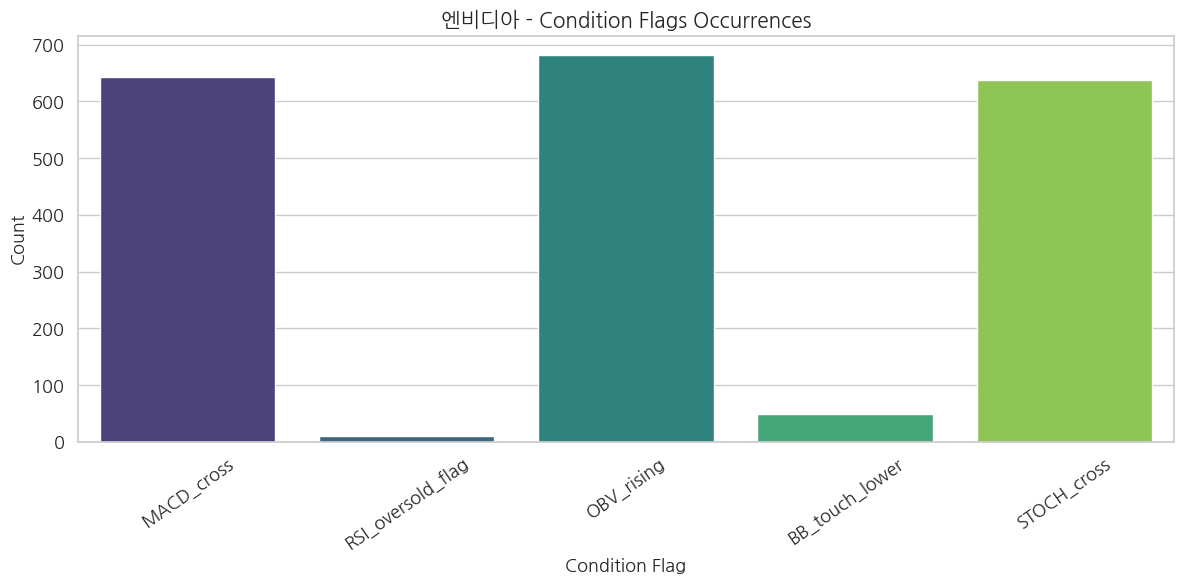

🖼️ Re-Plotting Flags for 알파벳 ...
✅ Saved: /home/nshawny/AI project 2/personal_data/eda_plots/알파벳_Flags_sns_v2.png


/tmp/ipykernel_1037/895526555.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=flag_df, x='Flag', y='Count', palette='viridis')


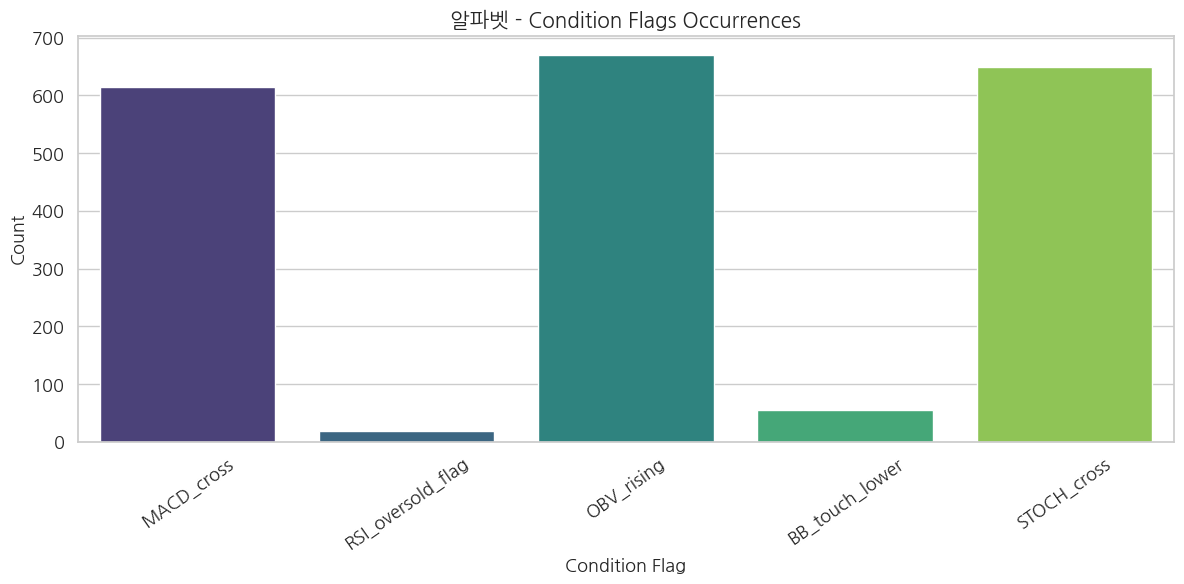

🖼️ Re-Plotting Flags for 애플 ...
✅ Saved: /home/nshawny/AI project 2/personal_data/eda_plots/애플_Flags_sns_v2.png


/tmp/ipykernel_1037/895526555.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=flag_df, x='Flag', y='Count', palette='viridis')


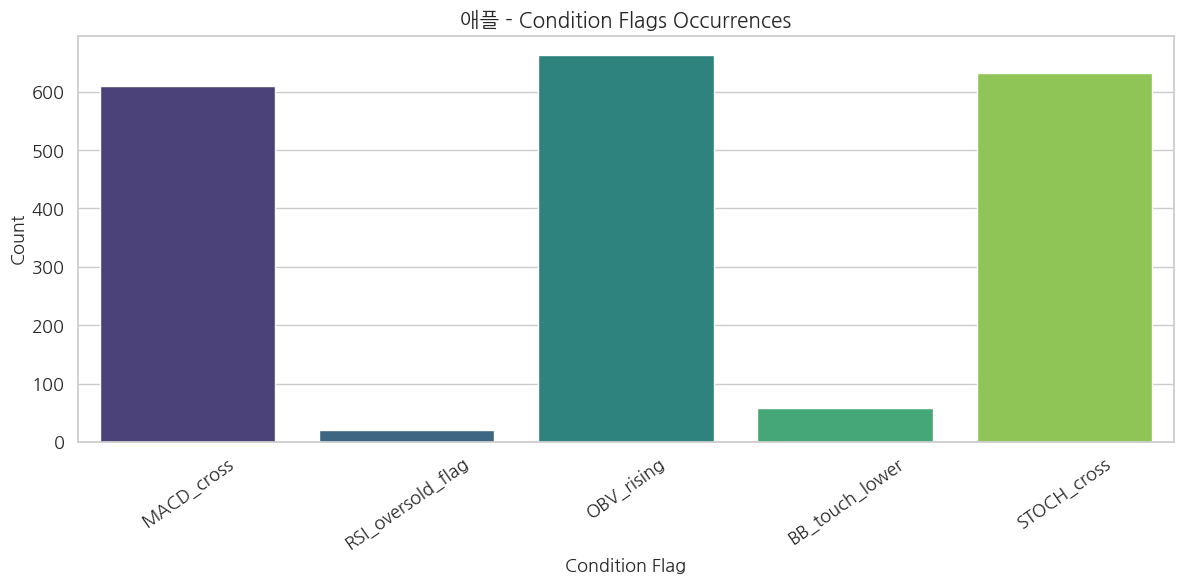

In [53]:
save_dir = '/home/nshawny/AI project 2/personal_data/eda_plots'

for name, df in features_dict.items():
    print(f'🖼️ Re-Plotting Flags for {name} ...')
    plot_condition_flags_seaborn_v2(
        df, 
        name, 
        save_path=save_dir,
        figsize=(12, 6),
        rotation=35,
        fontsize=13
    )

# 📊 종목별 Condition Flag 발생 빈도 해석 및 제안

---

## ✅ 알파벳 (Alphabet)

| Flag              | Count (대략) | 해석 및 제안 |
|--------------------|-------------|----------------|
| MACD_cross         | 610         | 적당히 풍부한 발생. MACD 기반 전략 설계 유효. 교차 시 수익률 변화 검정 권장. |
| RSI_oversold_flag  | 20          | 매우 희귀. 단일종목에서 검정 통계력 부족. 전종목 통합실험 고려. |
| OBV_rising         | 670         | 매우 자주 발생. 노이즈 가능성 ↑, 상승시 OBV 변화량 추가 Feature 설계 권장. |
| BB_touch_lower     | 50          | 드물게 발생. 극단상황 플래그로 전략화. 전종목 통합 혹은 다중조건 설계 필요. |
| STOCH_cross        | 640         | 자주 발생. 단독 사용시 정보량↓, RSI/OBV와 교차조건 실험 추천. |

---

## ✅ 애플 (Apple)

| Flag              | Count (대략) | 해석 및 제안 |
|--------------------|-------------|----------------|
| MACD_cross         | 610         | 충분한 발생 횟수. 단일 플래그 효과 검정 추천. |
| RSI_oversold_flag  | 20          | 매우 희귀. 단일조건 한계. 다른 조건과 결합 권장. |
| OBV_rising         | 660         | 발생 과다. OBV 단일보다 변화량/차분 활용 권장. |
| BB_touch_lower     | 50          | 희귀 조건. 극단적 신호로 분류. 다중조건 조합 실험. |
| STOCH_cross        | 630         | 풍부. Noise 가능성 고려. 교차조건으로 활용 가치 ↑. |

---

## ✅ 엔비디아 (Nvidia)

| Flag              | Count (대략) | 해석 및 제안 |
|--------------------|-------------|----------------|
| MACD_cross         | 640         | 발생량 충분. MACD 기반 신호 전략 실험 적합. |
| RSI_oversold_flag  | 10          | 매우 희귀. 단일 전략 통계력 한계. 전종목 통합 검정 고려. |
| OBV_rising         | 680         | 빈도 매우 높음. 노이즈 가능성. 롤링 OBV 변화량 파생 변수 설계 권장. |
| BB_touch_lower     | 50          | 드물게 발생. 극단적 상황 필터로 사용 가능. |
| STOCH_cross        | 640         | 풍부한 발생. 단일 플래그 노이즈↓, 조합 전략 설계 권장. |

---

## ✅ 📌 전반적 해석
- RSI_oversold_flag와 BB_touch_lower는 **매우 희귀** → 단독검정 힘들고 다중조건 실험·전종목 통합필요.
- MACD_cross, OBV_rising, STOCH_cross는 **발생빈도 매우 높음** → 단독 신호 약할 수 있음, 교차조합 필요.
- OBV_rising이 너무 자주 발생 → 단일변수는 노이즈성 높음. 변화량/차분 파생변수 추천.
- 전종목에서 분포 패턴이 매우 비슷 → 코드에서 신호 임계치가 종목 특성을 덜 반영했을 가능성 검토 권장.

---

## ✅ 📌 제안
- RSI/BB 기반 희귀 플래그 → 극단적 상황 필터 역할로 설정, 교차조건 전략화.
- OBV_rising → 단일 신호로는 약함, OBV 변화량이나 RSI/MACD와 조합.
- MACD_cross, STOCH_cross → 발생량 충분 → 단일/교차조건 수익률 검정 모두 가능.
- 플래그 기준치 튜닝 → 종목별 최적화 필요성 탐색.
- 전종목 공통코드 기준 → 종목별 변동성/스케일 차이를 반영하는 임계치 재설계 권장.

---


In [ ]:
def plot_scatter_relations(df, name, save_path=None):
    plt.figure(figsize=(12, 5))
    sns.scatterplot(x=df['RSI_14'], y=df['MACD_diff'])
    plt.title(f'{name} - RSI vs MACD_diff')
    if save_path:
        plt.savefig(f'{save_path}/{name}_RSI_MACD_scatter.png')
    plt.show()


In [ ]:
def plot_return_relation(df, name, save_path=None):
    plt.figure(figsize=(12, 5))
    sns.scatterplot(x=df['MACD_diff'], y=df['PriceChange_3d'])
    plt.title(f'{name} - PriceChange_3d vs MACD_diff')
    if save_path:
        plt.savefig(f'{save_path}/{name}_Return_MACD_scatter.png')
    plt.show()


In [ ]:
def plot_condition_boxplots(df, name, save_path=None):
    conditions = ['MACD_cross', 'RSI_oversold_flag', 'OBV_rising']
    plt.figure(figsize=(12, 6))
    for cond in conditions:
        sns.boxplot(x=df[cond], y=df['PriceChange_3d'])
        plt.title(f'{name} - PriceChange_3d by {cond}')
        if save_path:
            plt.savefig(f'{save_path}/{name}_{cond}_boxplot.png')
        plt.show()


In [55]:
# ✅ 저장 경로
save_dir = '/home/nshawny/AI project 2/personal_data/stock/overseas'

# ✅ 폴더가 없으면 생성
# os.makedirs(save_dir, exist_ok=True)

# ✅ features_dict -> CSV 저장
for name, df in features_dict.items():
    save_path = os.path.join(save_dir, f'{name}_features.csv')
    df.to_csv(save_path, index=False)
    print(f'✅ Saved: {save_path}')


✅ Saved: /home/nshawny/AI project 2/personal_data/stock/overseas/엔비디아_features.csv
✅ Saved: /home/nshawny/AI project 2/personal_data/stock/overseas/알파벳_features.csv
✅ Saved: /home/nshawny/AI project 2/personal_data/stock/overseas/애플_features.csv


# 📊 3종목 EDA 전반 해석 및 제안 요약

---

## ✅ 🍎 애플 (Apple)
- 완만한 상승+횡보 혼재형.
- 로그수익률 분포 중앙집중, Fat tail 약 → 단기 예측 가능성 양호.
- RSI/MACD_diff 균형적 분포 → 플래그 설계 용이.
- OBV 비정상성 강하고 이상치 많음 → 차분·변화량 필요.
- BB_ratio는 중심 밀집, 상하위 임계치 플래그 가능.

✅ **핵심:** 안정적 신호 설계 가능, 전통적 플래그 전략 적합.

---

## ✅ ⚡️ 엔비디아 (Nvidia)
- 극적인 장기 상승주 → 가격 스케일 변화 큼.
- 로그수익률 꼬리 매우 두꺼움 → 극단 이벤트 잦음.
- RSI 과매수 구간 비중 높음 → RSI>70 전략 유효 가능성.
- MACD_diff 꼬리 큼 → 변화율/롤링평균 활용 권장.
- OBV 급격한 변화 많음 → 로그변환·차분 필요.
- BB_ratio 상단 꼬리 뚜렷 → 밴드폭 확장기 전략 설계 적합.

✅ **핵심:** 강추세 대응 전략 필요, 극단치 관리 중요.

---

## ✅ 🔎 알파벳 (Alphabet)
- 완만한 상승세, 엔비디아보단 덜 극단적.
- 로그수익률 분포 좁고 중앙집중 → 예측 안정성 높음.
- RSI/MACD_diff 분포 대칭성 좋음 → 단일 임계치 플래그 설계 용이.
- OBV 다봉 분포, 이상치 많음 → 변화량 Feature 필수.
- BB_ratio 상하위 꼬리 존재 → 극단상황 플래그 설계 여지.

✅ **핵심:** 균형적 특성 → 전통 지표 플래그 전략이 잘 맞을 가능성.

---

## ✅ 📌 3 종목 공통적 전반 해석
- 로그수익률 모두 중앙집중 → **이진 타겟 설계 가능성 높음.**
- RSI 30~80 구간 넓게 분포 → 과매수/과매도 플래그 설계 충분.
- MACD_diff 중앙 0, 꼬리 큼 → 교차 신호 + 변화율 Feature 권장.
- OBV 비정상성, 이상치 다량 → 차분/변화율 파생변수 필수.
- BB_ratio 상하위 꼬리 존재 → 극단상황 플래그 설계 유효.

✅ **Theme:** 플래그 전략 + 변화량/차분 Feature 엔지니어링이 핵심.

---

## ✅ 📌 3 종목 총합 제안
⭐️ **조건별 평균 수익률 실험 설계**
- RSI<30, RSI>70
- MACD_cross 발생 여부
- OBV 상승/하락 변화율
- BB_ratio 상하위 10% 구간

⭐️ **MI/Spearman 분석 설계**
- 지표 원본/변화량 ↔ 3~5일 후 수익률
- 플래그 조합 ↔ 수익률 이진분류

⭐️ **정상성 검정**
- OBV, Close Price 차분 후 ADF
- 로그수익률은 대체로 정상성 가정

⭐️ **ML Feature Engineering**
- 지표 차분, 이동평균, 롤링 std
- 플래그 교호항, 조건별 조합
- Extreme event 플래그화

⭐️ **모델링 전략**
- RandomForest / XGBoost Feature Importance
- 이진 분류 (상승/하락) 라벨링
- 회귀 기반 로그수익률 예측

---

✅ **한 문장 정리**
> **이 세 종목 모두 단기 수익률 예측을 위한 기술적 지표 기반 신호 탐색이 가능하지만, OBV 차분/변화량 Feature, RSI/MACD 플래그 설계, BB_ratio 극단 상황 조건 등 지표별 특성에 맞춘 파생 변수 설계가 필수적이다.**
